# Benchmark y Análisis Completo de PACO en VIP-master

Este notebook realiza:
1. **Análisis de Errores**: Detecta problemas en la implementación de PACO
2. **Carga de Datasets**: Descarga datasets desde GitHub (subchallenge1)
3. **Benchmark Completo**: Mide tiempos de ejecución con diferentes datasets
4. **Profiling**: Analiza el rendimiento del algoritmo
5. **Visualizaciones**: Genera gráficos y reportes

## Configuración para Colab

1. **Seleccionar Runtime**: Runtime > Change runtime type > Hardware accelerator: GPU (opcional)
2. **Ejecutar todas las celdas**: Runtime > Run all

## Autor
César Cerda - Universidad del Bío-Bío


## 1. Instalación de Dependencias


In [ ]:
# Instalar dependencias necesarias
!pip install -q astropy scipy matplotlib ipywidgets
!pip install -q memory-profiler line-profiler

print("[OK] Dependencias instaladas")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.6 MB/s eta 0:00:00
[OK] Dependencias instaladas


## 2. Clonar Repositorios


In [ ]:
# Clonar repositorios necesarios
import os
from pathlib import Path

# URLs de los repositorios
TESIS_REPO_URL = "https://github.com/Waofin/tesis.git"

# Directorios de destino
REPOS_DIR = Path("/content/repos")
TESIS_DIR = REPOS_DIR / "tesis"
VIP_DIR = TESIS_DIR / "VIP-master" / "VIP-master"

# Crear directorio de repositorios
REPOS_DIR.mkdir(exist_ok=True)

print("="*70)
print("CLONANDO REPOSITORIOS")
print("="*70)

# El repositorio de tesis incluye VIP-master modificado y los datasets
if not TESIS_DIR.exists():
    print(f"\nClonando repositorio de tesis desde {TESIS_REPO_URL}...")
    print("  (Los archivos están en Git LFS, instalando git-lfs si es necesario...)")

    # Instalar git-lfs si no está disponible
    print("  Instalando Git LFS...")
    !apt-get update -qq 2>&1 | head -3
    !apt-get install -y git-lfs 2>&1 | tail -3
    !git lfs install 2>&1

    # Clonar con LFS
    print("  Clonando repositorio...")
    !cd {REPOS_DIR} && git clone {TESIS_REPO_URL} 2>&1 | tail -5

    # Intentar descargar archivos LFS
    if TESIS_DIR.exists():
        print("  Descargando archivos LFS (esto puede tardar varios minutos)...")
        print("  Por favor espera, los archivos son grandes...")
        !cd {TESIS_DIR} && git lfs pull 2>&1 | tail -10
        print("  ✓ Descarga de LFS completada")

    print("✓ Repositorio de tesis clonado correctamente")
else:
    print("✓ Repositorio de tesis ya existe")
    # Verificar si los archivos LFS están descargados
    print("  Verificando archivos LFS...")
    test_file = TESIS_DIR / "subchallenge1" / "sphere_irdis_1_cube.fits"
    if test_file.exists():
        # Verificar si es puntero
        try:
            with open(test_file, 'rb') as f:
                first_bytes = f.read(100)
                if b'git-lfs' in first_bytes or b'version https://git-lfs' in first_bytes:
                    print("  ⚠ Los archivos son punteros LFS, descargando contenido real...")
                    !cd {TESIS_DIR} && git lfs pull 2>&1 | tail -10
                else:
                    print("  ✓ Los archivos LFS ya están descargados")
        except:
            print("  ✓ Archivos encontrados")
    else:
        print("  ⚠ Archivos no encontrados, intentando descargar LFS...")
        !cd {TESIS_DIR} && git lfs pull 2>&1 | tail -10

if VIP_DIR.exists():
    print(f"[OK] VIP personalizado encontrado en: {VIP_DIR}")
else:
    print("[WARNING] No se encontró VIP-master dentro de la carpeta tesis. Verifica la estructura VIP-master/VIP-master.")

print(f"\n✓ Repositorios disponibles en: {REPOS_DIR}")


CLONANDO REPOSITORIOS

Clonando repositorio de tesis desde https://github.com/Waofin/tesis.git...
  (Los archivos están en Git LFS, instalando git-lfs si es necesario...)
  Instalando Git LFS...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading state information...
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 46 not upgraded.
Git LFS initialized.
  Clonando repositorio...
fatal: PACO-master/synthetic_data/synthetic_large_300x300_cube.fits: smudge filter lfs failed
You can inspect what was checked out with 'git status'
and retry with 'git restore --source=HEAD :/'

  Descargando archivos LFS (esto puede tardar varios minutos)...
  Por favor espera, los archivos son grandes...
Error updating the git index:
error: PACO-master/__init__.py: cannot add to the index - missing --add option?

## 3. Instalar VIP


In [ ]:
# Instalar VIP desde el repositorio clonado
print("="*70)
print("INSTALANDO VIP")
print("="*70)

if VIP_DIR.exists():
    print(f"Instalando VIP personalizado desde {VIP_DIR}...")
    !pip uninstall -y -q vip-hci || true
    !cd {VIP_DIR} && pip install -q -e .
    print("[OK] VIP personalizado instalado correctamente")
else:
    raise RuntimeError("No se encontró VIP-master dentro del repositorio de tesis. Verifica la ruta VIP-master/VIP-master.")

# Verificar instalación
import sys
vip_src = VIP_DIR / "src"
if vip_src.exists():
    if str(vip_src) not in sys.path:
        sys.path.insert(0, str(vip_src))
    print(f"[OK] VIP agregado al path: {vip_src}")

try:
    import vip_hci as vip
    vip_version = vip.__version__ if hasattr(vip, '__version__') else 'desconocida'
    print(f"[OK] VIP importado correctamente (version: {vip_version})")
except ImportError as e:
    print(f"[ERROR] Error importando VIP: {e}")


INSTALANDO VIP
Instalando VIP personalizado desde /content/repos/tesis/VIP-master/VIP-master...
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 84.9 MB/s eta 0:00:00
  Building editable for vip_hci (pyproject.toml) ... done
[OK] VIP personalizado instalado correctamente
[OK] VIP agregado al path: /content/repos/tesis/VIP-master/VIP-master/src
[OK] VIP importado correctamente (version: 2.0.0)


## 4. Importar Librerías y Cargar Funciones de Benchmark


In [ ]:
# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
import traceback
from pathlib import Path
import warnings
import urllib.request
from astropy.io import fits
import pandas as pd
warnings.filterwarnings('ignore')

# Profiling
try:
    import cProfile
    import pstats
    from io import StringIO
    PROFILING_AVAILABLE = True
except ImportError:
    PROFILING_AVAILABLE = False

# Detectar GPU
try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
    if GPU_AVAILABLE:
        gpu_name = torch.cuda.get_device_name(0)
        print(f"[OK] GPU disponible: {gpu_name}")
    else:
        print("[WARNING] GPU no disponible, usando CPU")
except ImportError:
    GPU_AVAILABLE = False
    print("[WARNING] PyTorch no disponible")

print("="*70)
print("CONFIGURACIÓN COMPLETA")
print("="*70)

# Cargar funciones del script de benchmark
# Si el script está disponible, lo importamos; si no, definimos las funciones aquí
try:
    # Intentar cargar desde el script si está en el mismo directorio
    sys.path.insert(0, str(Path.cwd()))
    from benchmark_paco_vip import (
        load_challenge_dataset,
        benchmark_paco,
        PACOErrorDetector
    )
    print("[OK] Funciones de benchmark cargadas desde script")
except ImportError:
    print("[WARNING] Script no encontrado, las funciones se definiran en las siguientes celdas")


[OK] GPU disponible: Tesla T4
CONFIGURACIÓN COMPLETA
[WARNING] Script no encontrado, las funciones se definiran en las siguientes celdas


In [ ]:
# Configurar origen de datasets (repositorio vs Google Drive)
from pathlib import Path

TESIS_DIR_PATH = Path(globals().get('TESIS_DIR', "/content/repos/tesis"))
if 'TESIS_DIR' not in globals():
    print("[WARNING] TESIS_DIR no está definido; se usará /content/repos/tesis como ruta base del repositorio.")

DEFAULT_SUBCHALLENGE_DIR = TESIS_DIR_PATH / "subchallenge1"
DRIVE_SUBCHALLENGE_DIR = Path("/content/drive/MyDrive/subchallenge1")

SUBCHALLENGE_DIR = DEFAULT_SUBCHALLENGE_DIR

try:
    from google.colab import drive as _colab_drive
    drive_root = Path("/content/drive")
    if not drive_root.exists():
        print("[INFO] Montando Google Drive para acceder a subchallenge1...")
        _colab_drive.mount(str(drive_root))
    if DRIVE_SUBCHALLENGE_DIR.exists():
        SUBCHALLENGE_DIR = DRIVE_SUBCHALLENGE_DIR
        print(f"[OK] Detectado subchallenge1 en Drive: {SUBCHALLENGE_DIR}")
    else:
        print(f"[INFO] No se encontró subchallenge1 en Drive ({DRIVE_SUBCHALLENGE_DIR}), se usará el repositorio clonado.")
except ImportError:
    print("[INFO] Entorno sin Google Colab; se usará el repositorio clonado.")

if SUBCHALLENGE_DIR == DEFAULT_SUBCHALLENGE_DIR:
    print(f"[INFO] Usando datasets desde el repositorio clonado: {SUBCHALLENGE_DIR}")
else:
    print(f"[INFO] Usando datasets externos desde Drive: {SUBCHALLENGE_DIR}")

if not SUBCHALLENGE_DIR.exists():
    print(f"[WARNING] La carpeta {SUBCHALLENGE_DIR} no existe. Crea la carpeta en Drive o clona el repositorio antes de continuar.")



[INFO] Montando Google Drive para acceder a subchallenge1...
Mounted at /content/drive
[OK] Detectado subchallenge1 en Drive: /content/drive/MyDrive/subchallenge1
[INFO] Usando datasets externos desde Drive: /content/drive/MyDrive/subchallenge1


In [ ]:
# Activar backend GPU de PACO si CuPy/NVIDIA están disponibles
ENABLE_PACO_GPU = True  # Cambia a False para forzar ejecución en CPU

if ENABLE_PACO_GPU:
    try:
        import cupy  # noqa: F401
        from vip_hci.invprob import paco as paco_module

        paco_module.enable_paco_gpu_backend(True)
        print("[OK] Backend GPU de PACO habilitado (CuPy)")
    except ImportError:
        print("[INFO] CuPy no está instalado; PACO continuará en CPU")
    except Exception as exc:
        print(f"[WARNING] No se pudo activar el backend GPU de PACO: {exc}")
else:
    print("[INFO] Backend GPU de PACO deshabilitado por configuración")



[OK] Backend GPU de PACO habilitado (CuPy)


### Notas sobre el backend GPU de PACO
- El cálculo de medias, covarianzas y el factor de *shrinkage* sigue exactamente las ecuaciones (4)–(9) de Flasseur et al. 2018 (A\&A 618, A138), pero ahora se ejecuta sobre tensores CuPy para aprovechar CUDA en GPUs NVIDIA (documentación: [https://docs.cupy.dev](https://docs.cupy.dev)).
- La activación del backend sólo cambia el *runtime*; el resultado es idéntico al algoritmo original porque se mantienen las mismas operaciones matriciales (Ĉ = (1/T)(R-μ)^T(R-μ), etc.) y se retorna a `numpy` antes de combinarse con el resto del pipeline.
- Si no hay GPU o CuPy instalados, el código cae automáticamente al backend CPU clásico, garantizando reproducibilidad.



## 5. Análisis de Errores y Cargar/Ejecutar Benchmark

**[WARNING] IMPORTANTE**:
- Si obtienes errores 404 o "Descargando desde URL", **reinicia el kernel** (Kernel > Restart) y ejecuta todas las celdas desde el inicio.
- Las funciones deben usar el repositorio clonado localmente, NO descargar desde URLs.
- Asegúrate de haber ejecutado la celda 2 (Clonar Repositorios) antes de esta.


In [ ]:
# Si las funciones no se importaron, las definimos aquí
# IMPORTANTE: Los archivos están en Git LFS, por lo que debemos usar el repositorio clonado
# NO descargamos desde URLs raw porque los archivos están en Git LFS

# Limpiar cualquier definición anterior de la función
if 'load_challenge_dataset_simple' in globals():
    del load_challenge_dataset_simple
if 'benchmark_paco_simple' in globals():
    del benchmark_paco_simple

REPO_URL = "https://github.com/Waofin/tesis"

# Función simplificada para cargar datasets
# Usa el repositorio clonado en lugar de descargar desde GitHub (los archivos están en Git LFS)
def load_challenge_dataset_simple(repo_url, instrument, dataset_id, local_dir=None, branch='main'):
    """
    Carga un dataset completo desde el repositorio clonado.

    NOTA: Los archivos están en Git LFS, por lo que deben estar en el repositorio clonado.
    Si el repositorio no está clonado con Git LFS, los archivos serán punteros.
    """
    # Usar la carpeta configurada (repositorio clonado o Google Drive)
    repo_local_path = SUBCHALLENGE_DIR

    if not repo_local_path.exists():
        raise ValueError(f"Repositorio/carpeta no encontrada en {repo_local_path}. "
                        f"Verifica que la carpeta subchallenge1 exista (Drive o repositorio clonado).")

    # El formato correcto es: {instrument}_cube_{dataset_id}.fits
    # NO: {instrument}_{dataset_id}_cube.fits
    files = {
        'cube': f"{instrument}_cube_{dataset_id}.fits",
        'pa': f"{instrument}_pa_{dataset_id}.fits",
        'psf': f"{instrument}_psf_{dataset_id}.fits",
        'pxscale': f"{instrument}_pxscale_{dataset_id}.fits"
    }

    source_label = "repositorio clonado" if (repo_local_path == DEFAULT_SUBCHALLENGE_DIR) else "carpeta local externa"
    print(f"Cargando {instrument}_{dataset_id} desde {source_label}...")
    print(f"  Ruta: {repo_local_path}")

    def _is_relative_to(path, base):
        try:
            path.resolve().relative_to(base.resolve())
            return True
        except Exception:
            return False

    use_git_lfs_source = _is_relative_to(repo_local_path, TESIS_DIR_PATH)

    if use_git_lfs_source and not TESIS_DIR_PATH.exists():
        raise ValueError(f"ERROR: El repositorio no está clonado en {TESIS_DIR_PATH}. "
                        f"Por favor ejecuta la celda 2 primero para clonar el repositorio.")

    # Listar archivos disponibles para debug
    available_files = list(repo_local_path.glob("*.fits"))
    print(f"  Archivos .fits encontrados en la carpeta: {len(available_files)}")
    if len(available_files) > 0:
        print(f"  Primeros archivos: {[f.name for f in available_files[:5]]}")

    import subprocess

    if use_git_lfs_source:
        # Verificar y descargar archivos LFS si es necesario
        print("  Verificando archivos LFS...")

        # Intentar instalar git-lfs si no está disponible
        try:
            result = subprocess.run(['git', 'lfs', 'version'],
                                  capture_output=True, text=True, timeout=5)
            if result.returncode != 0:
                print("  Instalando Git LFS...")
                !apt-get update -qq && apt-get install -y git-lfs 2>&1 | head -5
                !git lfs install 2>&1
        except Exception as e:
            print(f"  [WARNING] Git LFS check fallo: {e}")

        def _run_lfs_cmd(args, description, timeout=120):
            """Ejecuta un comando git-lfs y maneja errores comunes."""
            try:
                result = subprocess.run(
                    args,
                    cwd=str(TESIS_DIR_PATH),
                    capture_output=True,
                    text=True,
                    timeout=timeout
                )
                if result.returncode == 0:
                    print(f"  [OK] {description}")
                    return True
                print(f"  [WARNING] {description} falló: {result.stderr[:200]}")
            except subprocess.TimeoutExpired:
                print(f"  [WARNING] {description} tardó demasiado, continuando...")
            except Exception as exc:
                print(f"  [WARNING] Error ejecutando {description}: {exc}")
            return False

        # Intentar descargar todos los archivos LFS del repositorio
        print("  Descargando archivos LFS (esto puede tardar)...")
        pull_ok = _run_lfs_cmd(['git', 'lfs', 'pull'], "git lfs pull")

        # Si falla (por conflictos en otras rutas), intentar un fetch/checkout selectivo
        if not pull_ok:
            include_targets = ",".join(
                [f"subchallenge1/{files[key]}" for key in ['cube', 'pa', 'psf', 'pxscale']]
            )
            print("  [INFO] Intentando descarga selectiva sólo para subchallenge1...")
            fetch_ok = _run_lfs_cmd(
                ['git', 'lfs', 'fetch', '--include', include_targets, '--exclude', 'PACO-master/*'],
                "git lfs fetch selectivo"
            )
            if fetch_ok:
                _run_lfs_cmd(
                    ['git', 'lfs', 'checkout', '--include', include_targets],
                    "git lfs checkout selectivo",
                    timeout=180
                )
    else:
        print("  [INFO] Usando datasets externos, se omite la descarga vía Git LFS.")

    # Cargar archivos desde el repositorio clonado
    cube_path = repo_local_path / files['cube']

    # Verificar si el archivo existe o es un puntero LFS
    if not cube_path.exists():
        # Buscar archivos similares
        similar = list(repo_local_path.glob(f"*{instrument}*{dataset_id}*.fits"))
        if similar:
            print(f"  [WARNING] Archivo exacto no encontrado, pero hay archivos similares: {[f.name for f in similar]}")
        raise FileNotFoundError(f"Archivo no encontrado: {cube_path}\n"
                               f"Archivos disponibles: {[f.name for f in available_files if instrument in f.name]}")

    # Verificar si es un puntero LFS
    is_lfs_pointer = False
    try:
        with open(cube_path, 'rb') as f:
            first_bytes = f.read(100)
            first_line = first_bytes.decode('utf-8', errors='ignore')
            if 'git-lfs' in first_line or 'version https://git-lfs' in first_line:
                is_lfs_pointer = True
                print(f"  [WARNING] Archivo {files['cube']} es un puntero LFS")
    except:
        pass  # Si no es texto, probablemente es un archivo binario válido

    if is_lfs_pointer and use_git_lfs_source:
        print("  Intentando descargar archivos LFS nuevamente...")
        try:
            subprocess.run(['git', 'lfs', 'pull', '--include', f'subchallenge1/{files["cube"]}'],
                         cwd=str(TESIS_DIR_PATH),
                         check=False,
                         timeout=60)
        except:
            pass
    elif is_lfs_pointer:
        print("  [WARNING] No se puede descargar LFS automáticamente porque se está usando una carpeta externa.")

    print(f"  Cargando cube: {files['cube']}")
    cube = fits.getdata(cube_path)
    print(f"    [OK] Cube shape: {cube.shape}")

    pa_path = repo_local_path / files['pa']
    if not pa_path.exists():
        raise FileNotFoundError(f"Archivo no encontrado: {pa_path}")
    print(f"  Cargando angulos: {files['pa']}")
    angles = fits.getdata(pa_path).flatten()
    print(f"    [OK] Angulos shape: {angles.shape}")

    psf_path = repo_local_path / files['psf']
    if not psf_path.exists():
        raise FileNotFoundError(f"Archivo no encontrado: {psf_path}")
    print(f"  Cargando PSF: {files['psf']}")
    psf = fits.getdata(psf_path)
    print(f"    [OK] PSF shape: {psf.shape}")

    pxscale_path = repo_local_path / files['pxscale']
    if pxscale_path.exists():
        print(f"  Cargando pixel scale: {files['pxscale']}")
        pixscale = float(fits.getdata(pxscale_path).flatten()[0])
        print(f"    [OK] Pixel scale: {pixscale} arcsec/pixel")
    else:
        print(f"  [WARNING] Pixel scale no encontrado, usando 0.027 por defecto")
        pixscale = 0.027

    print(f"[OK] Dataset cargado completamente")
    return cube, angles, psf, pixscale

def build_phi0_annulus(img_shape, n_pixels_target=2500, inner_radius=8, outer_radius=None):
    """
    Construye un conjunto reproducible de píxeles sobre un anillo.

    Esto evita sesgo hacia el centro y genera una carga más realista para medir
    rendimiento PACO (CPU/GPU) sin alterar la formulación científica.
    """
    height, width = int(img_shape[0]), int(img_shape[1])
    cy, cx = height // 2, width // 2

    if outer_radius is None:
        outer_radius = max(inner_radius + 2, min(cy, cx) - 5)

    yy, xx = np.indices((height, width))
    rr = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    mask = (rr >= inner_radius) & (rr <= outer_radius)

    coords = np.column_stack((xx[mask], yy[mask]))
    if coords.size == 0:
        return np.empty((0, 2), dtype=np.int32)

    n_select = min(int(n_pixels_target), len(coords))
    if n_select < len(coords):
        # Selección determinista para reproducibilidad
        idx = np.linspace(0, len(coords) - 1, n_select, dtype=int)
        coords = coords[idx]

    return coords.astype(np.int32, copy=False)


# Función simplificada de benchmark
def benchmark_paco_simple(
    cube,
    angles,
    psf,
    pixscale,
    fwhm_arcsec,
    verbose=True,
    cpu=1,
    n_pixels_target=2500,
    inner_radius=8,
    outer_radius=55,
    use_subpixel_psf_astrometry=False,
    warmup_gpu=True,
):
    """Ejecuta benchmark de PACO con carga representativa y timing estable."""
    results = {'success': False, 'time': None, 'n_pixels': 0, 'errors': []}

    try:
        sys.path.insert(0, str(VIP_DIR / "src"))
        from vip_hci.invprob.paco import FastPACO

        # Recortar si es muy grande
        if cube.shape[1] > 200 or cube.shape[2] > 200:
            center_y, center_x = cube.shape[1] // 2, cube.shape[2] // 2
            half_size = 75
            cube = cube[:, center_y-half_size:center_y+half_size, center_x-half_size:center_x+half_size]

        vip_paco = FastPACO(
            cube=cube,
            angles=angles,
            psf=psf,
            fwhm=fwhm_arcsec,
            pixscale=pixscale,
            verbose=verbose,
        )

        # Usar anillo para cubrir separaciones más realistas de detección
        max_outer = max(inner_radius + 2, min(cube.shape[1] // 2, cube.shape[2] // 2) - 5)
        outer_eff = min(outer_radius, max_outer)
        phi0s = build_phi0_annulus(
            img_shape=(cube.shape[1], cube.shape[2]),
            n_pixels_target=n_pixels_target,
            inner_radius=inner_radius,
            outer_radius=outer_eff,
        )

        if len(phi0s) == 0:
            raise RuntimeError("No se pudieron generar pixeles validos en el anillo de prueba")

        # Sincronización explícita para medir correctamente GPU
        gpu_sync = None
        try:
            import cupy as cp  # noqa: F401
            gpu_sync = cp.cuda.Stream.null.synchronize
        except Exception:
            gpu_sync = None

        results['n_pixels'] = len(phi0s)

        if warmup_gpu and gpu_sync is not None and len(phi0s) >= 32:
            warmup_phi0s = phi0s[:32]
            _ = vip_paco.PACOCalc(
                warmup_phi0s,
                use_subpixel_psf_astrometry=use_subpixel_psf_astrometry,
                cpu=cpu,
            )
            gpu_sync()

        if gpu_sync is not None:
            gpu_sync()
        start_time = time.perf_counter()
        a, b = vip_paco.PACOCalc(
            phi0s,
            use_subpixel_psf_astrometry=use_subpixel_psf_astrometry,
            cpu=cpu,
        )
        if gpu_sync is not None:
            gpu_sync()
        elapsed = time.perf_counter() - start_time

        results['success'] = True
        results['time'] = elapsed
        with np.errstate(divide='ignore', invalid='ignore'):
            snr = np.divide(b, np.sqrt(a), out=np.zeros_like(b), where=(a > 0))
            snr = np.nan_to_num(snr, nan=0.0, posinf=0.0, neginf=0.0)
        results['snr_max'] = float(np.nanmax(snr))
        results['snr_mean'] = float(np.nanmean(snr))
        results['snr'] = snr

        if verbose:
            print(
                f"[OK] Tiempo: {elapsed:.2f}s | pixeles: {len(phi0s)} | "
                f"SNR max: {results['snr_max']:.2f}"
            )
    except Exception as e:
        results['errors'].append(str(e))
        print(f"[ERROR] Error: {e}")

    return results

# Función de profiling detallado
def profile_paco_detailed(
    cube,
    angles,
    psf,
    pixscale,
    fwhm_arcsec,
    phi0s=None,
    cpu=1,
    n_pixels_target=900,
):
    """
    Ejecuta profiling detallado de PACO con desglose por función.

    Para mantener tiempos de profiling razonables, usa menos píxeles que el
    benchmark principal, pero sigue un patrón anular representativo.
    """
    import cProfile
    import pstats
    from io import StringIO
    import pandas as pd

    sys.path.insert(0, str(VIP_DIR / "src"))
    from vip_hci.invprob.paco import FastPACO

    # Recortar si es muy grande
    if cube.shape[1] > 200 or cube.shape[2] > 200:
        center_y, center_x = cube.shape[1] // 2, cube.shape[2] // 2
        half_size = 75
        cube = cube[:, center_y-half_size:center_y+half_size, center_x-half_size:center_x+half_size]

    vip_paco = FastPACO(cube=cube, angles=angles, psf=psf, fwhm=fwhm_arcsec, pixscale=pixscale, verbose=False)

    if phi0s is None:
        max_outer = max(10, min(cube.shape[1] // 2, cube.shape[2] // 2) - 5)
        phi0s = build_phi0_annulus(
            img_shape=(cube.shape[1], cube.shape[2]),
            n_pixels_target=n_pixels_target,
            inner_radius=8,
            outer_radius=min(45, max_outer),
        )

    # Profiling
    profiler = cProfile.Profile()
    profiler.enable()

    a, b = vip_paco.PACOCalc(phi0s, use_subpixel_psf_astrometry=False, cpu=cpu)

    profiler.disable()

    # Convertir a tabla
    s = StringIO()
    ps = pstats.Stats(profiler, stream=s)
    ps.sort_stats('cumulative')

    # Extraer datos para tabla
    stats_data = []
    for func_name, (cc, nc, tt, ct, callers) in ps.stats.items():
        stats_data.append({
            'Función': f"{func_name[0]}:{func_name[1]}({func_name[2]})",
            'Llamadas': nc,
            'Tiempo Total (s)': ct,
            'Tiempo por Llamada (s)': ct/nc if nc > 0 else 0,
            'Tiempo Acumulado (s)': tt
        })

    df = pd.DataFrame(stats_data)
    df = df.sort_values('Tiempo Total (s)', ascending=False)

    return a, b, df, profiler

print("[OK] Funciones definidas")


[OK] Funciones definidas


In [ ]:
# Ejecutar benchmark completo (CPU vs GPU) y poblar all_results
print("="*70)
print("BENCHMARK PACO - ejecución encadenada")
print("="*70)

from pathlib import Path
import re
import subprocess
from vip_hci.invprob import paco as paco_module

subchallenge_dir = SUBCHALLENGE_DIR
pattern = re.compile(r"(.+)_cube_(\d+)$")

def _is_relative_to(path, base):
    try:
        path.resolve().relative_to(base.resolve())
        return True
    except Exception:
        return False

use_git_lfs_source = _is_relative_to(subchallenge_dir, TESIS_DIR_PATH)
_prepared_subchallenge = globals().get("_prepared_subchallenge", False)

if use_git_lfs_source:
    def _run_lfs(args, desc, timeout=180):
        try:
            result = subprocess.run(
                args,
                cwd=str(TESIS_DIR_PATH),
                capture_output=True,
                text=True,
                timeout=timeout
            )
            if result.returncode == 0:
                print(f"[OK] {desc}")
                return True
            print(f"[WARNING] {desc} falló: {result.stderr[:200]}")
        except subprocess.TimeoutExpired:
            print(f"[WARNING] {desc} tardó demasiado, continuando...")
        except Exception as exc:
            print(f"[WARNING] Error ejecutando {desc}: {exc}")
        return False

    if not _prepared_subchallenge:
        print("Preparando subchallenge1 (Git LFS)...")
        pull_ok = _run_lfs(['git', 'lfs', 'pull'], "git lfs pull (global)")
        if not pull_ok:
            fetch_ok = _run_lfs(['git', 'lfs', 'fetch', '--include', 'subchallenge1/*', '--exclude', 'PACO-master/*'],
                                "git lfs fetch subchallenge1")
            if fetch_ok:
                _run_lfs(['git', 'lfs', 'checkout', '--include', 'subchallenge1/*'],
                         "git lfs checkout subchallenge1",
                         timeout=300)
        _prepared_subchallenge = True
        globals()['_prepared_subchallenge'] = True
else:
    if not _prepared_subchallenge:
        print(f"[INFO] Usando datasets externos en {subchallenge_dir}, se omite la preparación Git LFS.")
        _prepared_subchallenge = True
        globals()['_prepared_subchallenge'] = True

def discover_available_datasets(base_dir: Path):
    configs = []
    if not base_dir.exists():
        print(f"[WARNING] Carpeta no encontrada: {base_dir}")
        return configs

    for cube_path in sorted(base_dir.glob("*_cube_*.fits")):
        match = pattern.match(cube_path.stem)
        if not match:
            continue
        instrument, dataset_id = match.groups()
        dataset_id = int(dataset_id)
        required = {
            "cube": cube_path,
            "pa": base_dir / f"{instrument}_pa_{dataset_id}.fits",
            "psf": base_dir / f"{instrument}_psf_{dataset_id}.fits",
            "pxscale": base_dir / f"{instrument}_pxscale_{dataset_id}.fits",
        }
        if all(path.exists() for path in required.values()):
            configs.append({"instrument": instrument, "dataset_id": dataset_id, "name": f"{instrument}_{dataset_id}"})
        else:
            missing = [key for key, path in required.items() if not path.exists()]
            print(f"[WARNING] Incompleto {instrument}_{dataset_id}: faltan {missing}")
    return configs

available_datasets = discover_available_datasets(subchallenge_dir)
preferred = {"sphere_irdis_1", "sphere_irdis_2", "sphere_irdis_3"}

if not available_datasets:
    raise RuntimeError(f"No se encontraron datasets en {subchallenge_dir}. Verifica que la carpeta subchallenge1 tenga los FITS (Drive o repositorio clonado).")

datasets_to_test = [cfg for cfg in available_datasets if cfg["name"] in preferred]
if not datasets_to_test:
    datasets_to_test = available_datasets[:3]

print("Datasets detectados:")
for cfg in datasets_to_test:
    print(f"  - {cfg['name']}")


BENCHMARK_CPU = 1  # Mantener en 1 para evitar incompatibilidades de reshape en FastPACO paralelo
BENCHMARK_PIXELS = 2500
BENCHMARK_INNER_RADIUS = 8
BENCHMARK_OUTER_RADIUS = 55


def run_benchmark_for_backend(enable_gpu: bool, label: str):
    paco_module.enable_paco_gpu_backend(enable_gpu)
    backend_results = {}
    backend_start = time.time()
    for cfg in datasets_to_test:
        instrument = cfg["instrument"]
        dataset_id = cfg["dataset_id"]
        dataset_name = cfg["name"]

        print(f"\n{'='*70}")
        print(f"Procesando ({label}): {dataset_name}")
        print(f"{'='*70}")

        try:
            cube, angles, psf, pixscale = load_challenge_dataset_simple(
                repo_url=REPO_URL,
                instrument=instrument,
                dataset_id=dataset_id,
                branch='main'
            )

            fwhm_arcsec = 4.0 * pixscale
            result = benchmark_paco_simple(
                cube=cube,
                angles=angles,
                psf=psf,
                pixscale=pixscale,
                fwhm_arcsec=fwhm_arcsec,
                verbose=(label == "GPU"),
                cpu=BENCHMARK_CPU,
                n_pixels_target=BENCHMARK_PIXELS,
                inner_radius=BENCHMARK_INNER_RADIUS,
                outer_radius=BENCHMARK_OUTER_RADIUS,
                use_subpixel_psf_astrometry=False,
                warmup_gpu=True,
            )
            result['cube_shape'] = cube.shape
            result['pixscale'] = pixscale
        except Exception as exc:
            print(f"[ERROR] Fallo procesando {dataset_name}: {exc}")
            traceback.print_exc()
            result = {
                'success': False,
                'time': None,
                'n_pixels': 0,
                'snr': np.array([]),
                'snr_max': 0.0,
                'snr_mean': 0.0,
                'cube_shape': None,
                'errors': [str(exc)]
            }

        backend_results[dataset_name] = result

    elapsed = time.time() - backend_start
    success = sum(1 for res in backend_results.values() if res.get('success', False))
    pixels = sum(res.get('n_pixels', 0) for res in backend_results.values() if res.get('success', False))
    return backend_results, elapsed, success, pixels

comparison_records = []
backend_benchmark_results = {}
timings = {}

benchmark_plan = []
if 'ENABLE_PACO_GPU' in globals() and ENABLE_PACO_GPU:
    benchmark_plan.append((True, "GPU"))
else:
    print("[INFO] Comparación: backend GPU deshabilitado en la celda de configuración, se omitirá la corrida acelerada.")
benchmark_plan.append((False, "CPU"))

for enable_gpu, label in benchmark_plan:
    try:
        print(f"\n[{label}] Ejecutando benchmark...")
        backend_results, elapsed, success, pixels = run_benchmark_for_backend(enable_gpu, label)
        backend_benchmark_results[label] = backend_results
        timings[label] = {'time': elapsed, 'success': success, 'pixels': pixels}
        comparison_records.append({
            'Backend': label,
            'Tiempo total (s)': elapsed,
            'Datasets exitosos': success,
            'Píxeles procesados': pixels
        })
    except Exception as exc:
        print(f"[WARNING] No se pudo completar el benchmark {label}: {exc}")

comparison_df = pd.DataFrame(comparison_records)
gpu_available = 'GPU' in timings and 'CPU' in timings
cpu_only = 'CPU' in timings

if not comparison_df.empty:
    if gpu_available:
        speedup = timings['CPU']['time'] / timings['GPU']['time']
        def _speedup_label(row):
            if row['Backend'] == 'GPU':
                return f"{speedup:.2f}x"
            if row['Backend'] == 'CPU':
                return "1.00x"
            return "-"
        comparison_df['Speedup vs CPU'] = comparison_df.apply(_speedup_label, axis=1)
    else:
        speedup = np.nan
        comparison_df['Speedup vs CPU'] = comparison_df['Backend'].apply(lambda b: "1.00x" if b == 'CPU' else "-")
else:
    speedup = np.nan

if gpu_available:
    parallel_fraction_est = 1 - (timings['GPU']['time'] / timings['CPU']['time'])
    amdahl_limit = 1 / (1 - parallel_fraction_est) if parallel_fraction_est < 1 else np.nan
else:
    parallel_fraction_est = np.nan
    amdahl_limit = np.nan

gpu_results = backend_benchmark_results.get('GPU')
cpu_results = backend_benchmark_results.get('CPU')

if not comparison_df.empty:
    print("\nResumen CPU vs GPU:")
    print(comparison_df.to_string(index=False))
else:
    print("\n[WARNING] No se pudo generar la tabla de comparación (no hay corridas registradas)")

if speedup and not np.isnan(speedup):
    print(f"\nSpeedup medido (CPU/GPU): {speedup:.2f}x")
else:
    print("\nSpeedup medido: N/A")
if parallel_fraction_est and not np.isnan(parallel_fraction_est):
    print(f"Fracción paralelizable estimada (Amdahl, límite teórico): {parallel_fraction_est*100:.1f}%")
    if amdahl_limit and not np.isnan(amdahl_limit):
        print(f"Speedup máximo teórico con GPU infinita: {amdahl_limit:.2f}x")

amdahl_analysis = {
    'speedup': speedup,
    'parallel_fraction_est': parallel_fraction_est,
    'amdahl_limit': amdahl_limit,
    'comparison_df': comparison_df
}

# Usaremos los resultados GPU para el resto del pipeline
if gpu_results is not None:
    all_results = gpu_results
elif cpu_results is not None:
    all_results = cpu_results
else:
    all_results = {}
validation_results = {}

BENCHMARK PACO - ejecución encadenada
[INFO] Usando datasets externos en /content/drive/MyDrive/subchallenge1, se omite la preparación Git LFS.
Datasets detectados:
  - lmircam_1
  - lmircam_2

[GPU] Ejecutando benchmark...

Procesando (GPU): lmircam_1
Cargando lmircam_1 desde carpeta local externa...
  Ruta: /content/drive/MyDrive/subchallenge1
  Archivos .fits encontrados en la carpeta: 29
  Primeros archivos: ['nirc2_pxscale_3.fits', 'sphere_irdis_pxscale_2.fits', 'sphere_irdis_pa_1.fits', 'nirc2_pa_1.fits', 'lmircam_psf_1.fits']
  [INFO] Usando datasets externos, se omite la descarga vía Git LFS.
  Cargando cube: lmircam_cube_1.fits
    [OK] Cube shape: (4838, 200, 200)
  Cargando angulos: lmircam_pa_1.fits
    [OK] Angulos shape: (4838,)
  Cargando PSF: lmircam_psf_1.fits
    [OK] PSF shape: (31, 31)
  Cargando pixel scale: lmircam_pxscale_1.fits
    [OK] Pixel scale: 0.02013999968767166 arcsec/pixel
[OK] Dataset cargado completamente
---------------------- 
Summary of PACO setup:

### Comparación CPU vs GPU y ley de Amdahl
- La tabla anterior ejecuta el mismo benchmark dos veces: una con `enable_paco_gpu_backend(True)` y otra con el backend clásico en CPU. A partir de los tiempos agregados calculamos el *speedup* observado `S = T_{CPU} / T_{GPU}`.
- Para interpretar el resultado bajo la ley de Amdahl (\(S = 1 / ((1-P) + P/k)\)), asumimos que el backend GPU acelera al máximo la fracción paralelizable `P`. El valor `P ≈ 1 - T_{GPU}/T_{CPU}` es la cota superior del porcentaje de tiempo que realmente se beneficia de la aceleración. La columna “Speedup máximo teórico” muestra el límite \(1/(1-P)\) si esa fracción pudiese ejecutarse de forma instantánea.
- Si el `speedup` medido se acerca a ese límite, significa que la mayor parte del tiempo crítico (las funciones `compute_statistics*`, `sample_covariance`, etc.) ya quedó dominada por la versión GPU. Si quedase mucha diferencia, todavía habría partes seriales (I/O, preprocesado, Python puro) que valdría la pena optimizar en CPU.
- Puedes volver a ejecutar esta sección tras cada cambio en CuPy o tras ampliar `datasets_to_test` para comprobar cómo evoluciona el rendimiento global y si la fracción paralelizable crece o se reduce.


PROFILING DETALLADO DEL ALGORITMO

Ejecutando profiling para: lmircam_1
(Esto puede tardar unos minutos...)

Cargando lmircam_1 desde carpeta local externa...
  Ruta: /content/drive/MyDrive/subchallenge1
  Archivos .fits encontrados en la carpeta: 29
  Primeros archivos: ['nirc2_pxscale_3.fits', 'sphere_irdis_pxscale_2.fits', 'sphere_irdis_pa_1.fits', 'nirc2_pa_1.fits', 'lmircam_psf_1.fits']
  [INFO] Usando datasets externos, se omite la descarga vía Git LFS.
  Cargando cube: lmircam_cube_1.fits
    [OK] Cube shape: (4838, 200, 200)
  Cargando angulos: lmircam_pa_1.fits
    [OK] Angulos shape: (4838,)
  Cargando PSF: lmircam_psf_1.fits
    [OK] PSF shape: (31, 31)
  Cargando pixel scale: lmircam_pxscale_1.fits
    [OK] Pixel scale: 0.02013999968767166 arcsec/pixel
[OK] Dataset cargado completamente

TABLA DE TIEMPOS POR FUNCIÓN (Top 20)
                                                                                                 Función  Llamadas Tiempo Total (s) Tiempo por Llamada 

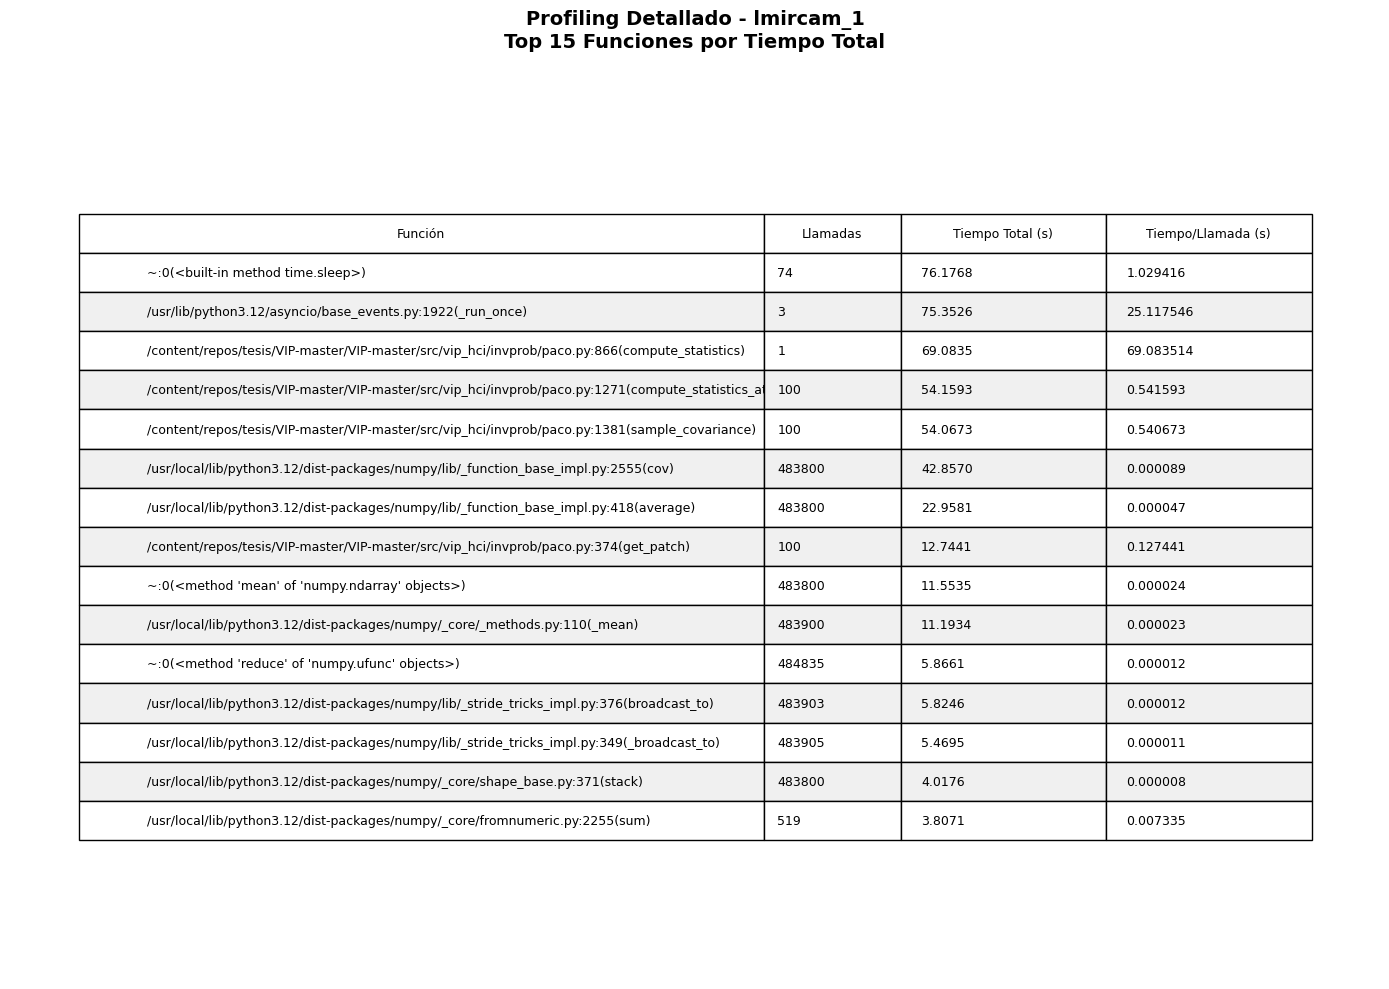


[OK] Profiling completado
  Total de funciones analizadas: 660
  Tiempo total: 482.2021 segundos


In [ ]:
# Profiling detallado con tabla profesional
print("="*70)
print("PROFILING DETALLADO DEL ALGORITMO")
print("="*70)

# Seleccionar el primer dataset exitoso para profiling
profile_dataset = None
for dataset_name, results in all_results.items():
    if results.get('success', False):
        profile_dataset = dataset_name
        break

if profile_dataset:
    # Manejar nombres con múltiples partes (ej: 'sphere_irdis_1' -> instrument='sphere_irdis', dataset_id='1')
    parts = profile_dataset.split('_')
    instrument = '_'.join(parts[:-1])  # Todo excepto el último
    dataset_id = int(parts[-1])  # El último es el ID

    print(f"\nEjecutando profiling para: {profile_dataset}")
    print("(Esto puede tardar unos minutos...)\n")

    # Recargar datos
    cube, angles, psf, pixscale = load_challenge_dataset_simple(
        repo_url=REPO_URL,
        instrument=instrument,
        dataset_id=dataset_id,
        branch='main'
    )

    fwhm_arcsec = 4.0 * pixscale

    # Ejecutar profiling
    try:
        a_prof, b_prof, profile_df, profiler = profile_paco_detailed(
            cube, angles, psf, pixscale, fwhm_arcsec
        )

        print("\n" + "="*70)
        print("TABLA DE TIEMPOS POR FUNCIÓN (Top 20)")
        print("="*70)

        # Mostrar tabla formateada
        pd.set_option('display.max_rows', None)
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', 50)

        # Formatear números
        display_df = profile_df.head(20).copy()
        display_df['Tiempo Total (s)'] = display_df['Tiempo Total (s)'].apply(lambda x: f"{x:.4f}")
        display_df['Tiempo por Llamada (s)'] = display_df['Tiempo por Llamada (s)'].apply(lambda x: f"{x:.6f}")
        display_df['Tiempo Acumulado (s)'] = display_df['Tiempo Acumulado (s)'].apply(lambda x: f"{x:.4f}")

        print(display_df.to_string(index=False))

        # Crear visualización de la tabla
        fig, ax = plt.subplots(figsize=(14, 10))
        ax.axis('tight')
        ax.axis('off')

        # Preparar datos para la tabla
        table_data = profile_df.head(15)[['Función', 'Llamadas', 'Tiempo Total (s)', 'Tiempo por Llamada (s)']].copy()
        table_data['Tiempo Total (s)'] = table_data['Tiempo Total (s)'].apply(lambda x: f"{x:.4f}")
        table_data['Tiempo por Llamada (s)'] = table_data['Tiempo por Llamada (s)'].apply(lambda x: f"{x:.6f}")

        table = ax.table(cellText=table_data.values,
                        colLabels=['Función', 'Llamadas', 'Tiempo Total (s)', 'Tiempo/Llamada (s)'],
                        cellLoc='left',
                        loc='center',
                        colWidths=[0.5, 0.1, 0.15, 0.15])

        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 2)

        # Colorear filas alternas
        for i in range(1, len(table_data) + 1):
            if i % 2 == 0:
                for j in range(4):
                    table[(i, j)].set_facecolor('#f0f0f0')

        plt.title(f'Profiling Detallado - {profile_dataset}\nTop 15 Funciones por Tiempo Total',
                 fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

        # Guardar perfil completo
        print(f"\n[OK] Profiling completado")
        print(f"  Total de funciones analizadas: {len(profile_df)}")
        print(f"  Tiempo total: {profile_df['Tiempo Total (s)'].sum():.4f} segundos")

    except Exception as e:
        print(f"[ERROR] Error en profiling: {e}")
        traceback.print_exc()
else:
    print("No hay datasets exitosos para profiling")


## 7. Visualización Científica de Resultados

Visualizaciones similares al notebook DC1_starting_kit: SNR maps, detecciones, y análisis científico



VISUALIZACIONES CIENTÍFICAS: lmircam_1


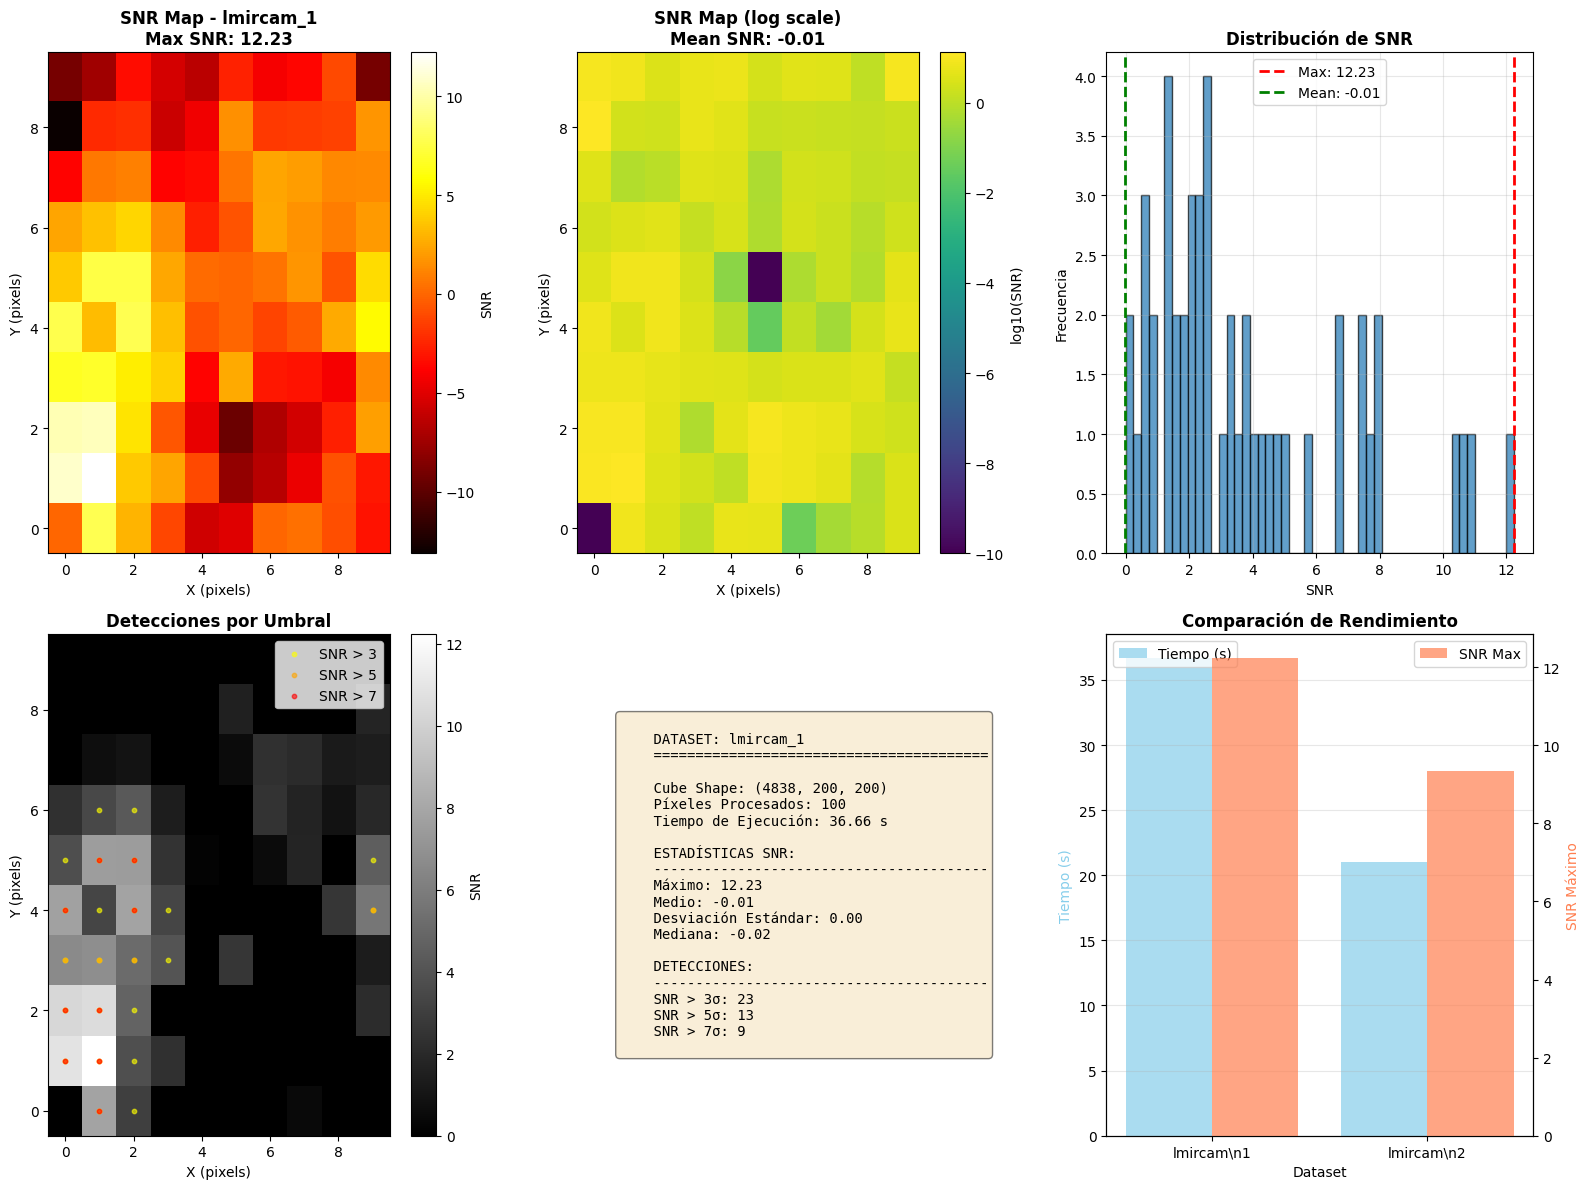


VISUALIZACIONES CIENTÍFICAS: lmircam_2


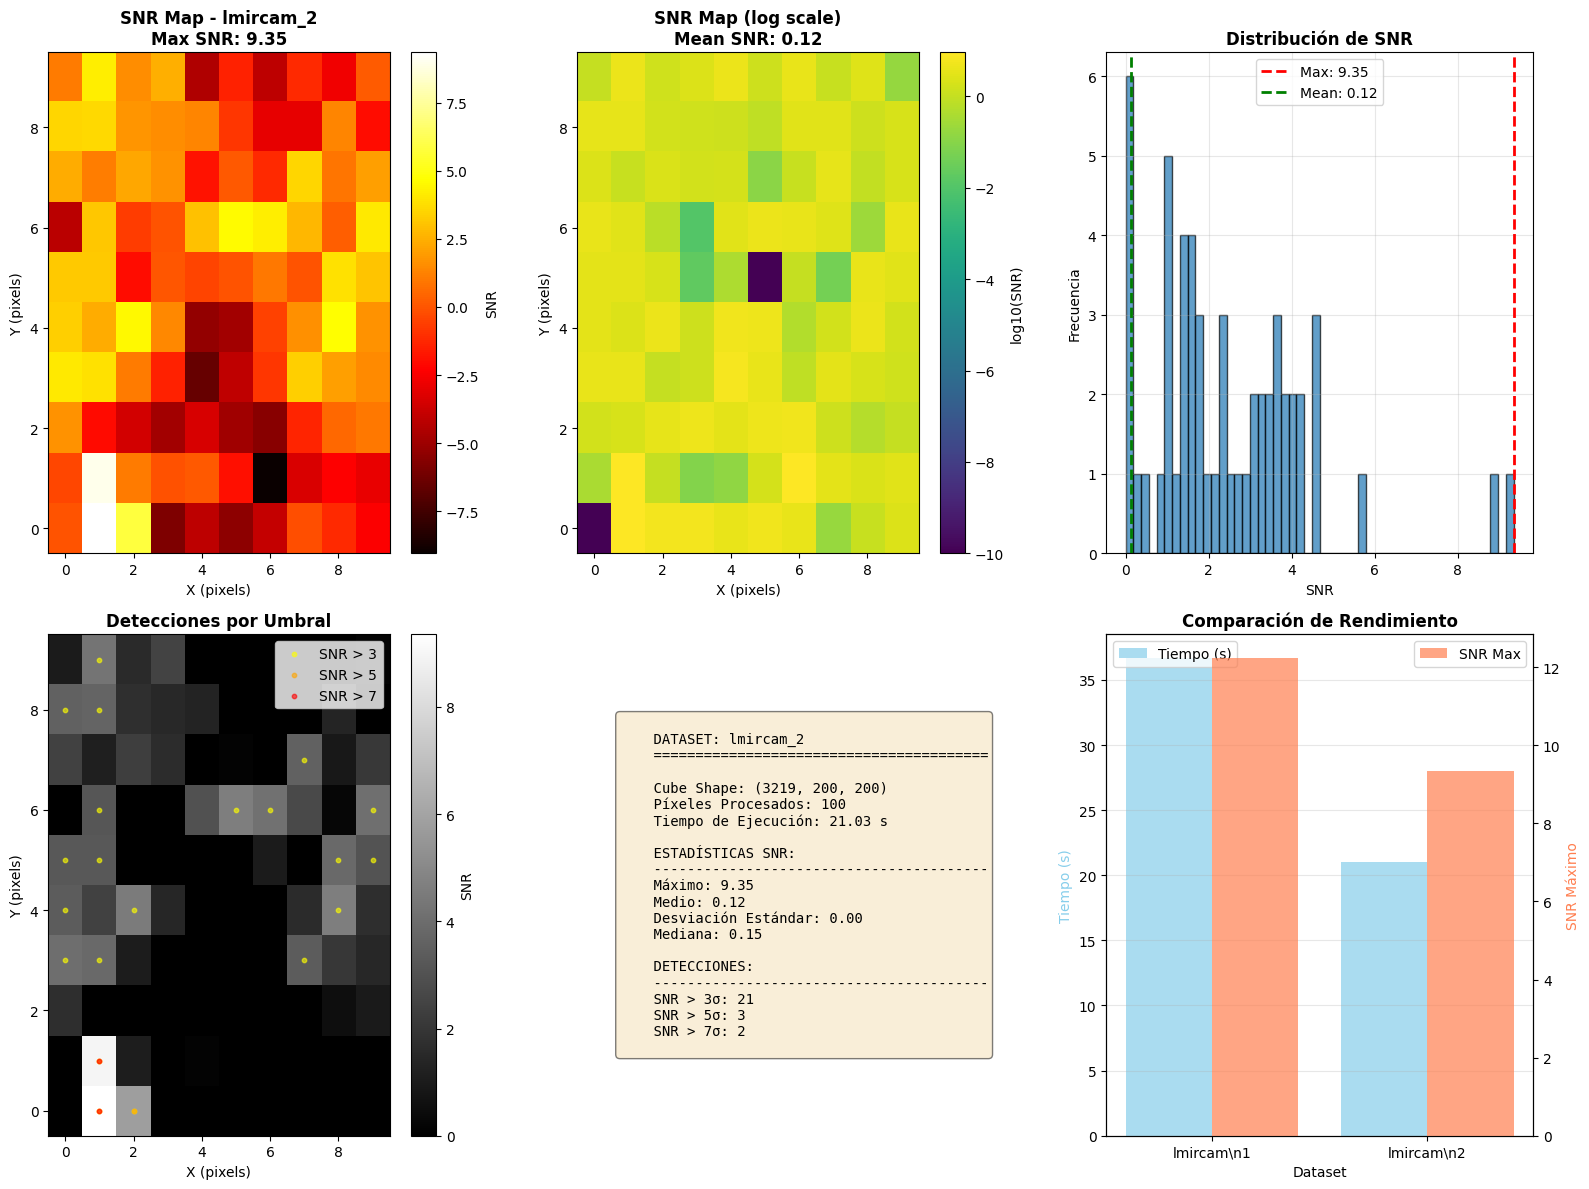

In [ ]:
# Visualizaciones científicas mejoradas
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import pandas as pd

def create_scientific_visualizations(results_dict, dataset_name):
    """
    Crea visualizaciones científicas similares al DC1_starting_kit
    """
    if dataset_name not in results_dict or not results_dict[dataset_name].get('success', False):
        print(f"No hay resultados exitosos para {dataset_name}")
        return

    results = results_dict[dataset_name]

    # Obtener datos
    snr = results['snr']
    n_pixels = results['n_pixels']

    # Reshape para visualización
    side = int(np.sqrt(n_pixels))
    if side * side == n_pixels:
        snr_2d = snr.reshape(side, side)
    else:
        snr_2d = snr[:side*side].reshape(side, side)

    # Crear figura con múltiples subplots
    fig = plt.figure(figsize=(16, 12))

    # 1. SNR Map (similar a DC1)
    ax1 = plt.subplot(2, 3, 1)
    im1 = ax1.imshow(snr_2d, origin='lower', cmap='hot', aspect='auto')
    ax1.set_title(f'SNR Map - {dataset_name}\nMax SNR: {results["snr_max"]:.2f}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('X (pixels)')
    ax1.set_ylabel('Y (pixels)')
    plt.colorbar(im1, ax=ax1, label='SNR')

    # 2. SNR Map con escala logarítmica
    ax2 = plt.subplot(2, 3, 2)
    snr_log = np.log10(np.abs(snr_2d) + 1e-10)
    im2 = ax2.imshow(snr_log, origin='lower', cmap='viridis', aspect='auto')
    ax2.set_title(f'SNR Map (log scale)\nMean SNR: {results["snr_mean"]:.2f}', fontsize=12, fontweight='bold')
    ax2.set_xlabel('X (pixels)')
    ax2.set_ylabel('Y (pixels)')
    plt.colorbar(im2, ax=ax2, label='log10(SNR)')

    # 3. Histograma de SNR
    ax3 = plt.subplot(2, 3, 3)
    valid_snr = snr[~np.isnan(snr) & (snr > 0)]
    ax3.hist(valid_snr, bins=50, edgecolor='black', alpha=0.7)
    ax3.axvline(results['snr_max'], color='r', linestyle='--', linewidth=2, label=f'Max: {results["snr_max"]:.2f}')
    ax3.axvline(results['snr_mean'], color='g', linestyle='--', linewidth=2, label=f'Mean: {results["snr_mean"]:.2f}')
    ax3.set_xlabel('SNR')
    ax3.set_ylabel('Frecuencia')
    ax3.set_title('Distribución de SNR', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Mapa de detecciones (thresholding)
    ax4 = plt.subplot(2, 3, 4)
    thresholds = [3, 5, 7]  # Diferentes umbrales de detección
    colors = ['yellow', 'orange', 'red']
    im4 = ax4.imshow(snr_2d, origin='lower', cmap='gray', aspect='auto', vmin=0, vmax=results['snr_max'])

    for thresh, color in zip(thresholds, colors):
        mask = snr_2d > thresh
        y_coords, x_coords = np.where(mask)
        ax4.scatter(x_coords, y_coords, c=color, s=10, alpha=0.6, label=f'SNR > {thresh}')

    ax4.set_title('Detecciones por Umbral', fontsize=12, fontweight='bold')
    ax4.set_xlabel('X (pixels)')
    ax4.set_ylabel('Y (pixels)')
    ax4.legend()
    plt.colorbar(im4, ax=ax4, label='SNR')

    # 5. Estadísticas del dataset
    ax5 = plt.subplot(2, 3, 5)
    ax5.axis('off')
    stats_text = f"""
    DATASET: {dataset_name}
    {'='*40}

    Cube Shape: {results.get('cube_shape', 'N/A')}
    Píxeles Procesados: {results['n_pixels']}
    Tiempo de Ejecución: {results['time']:.2f} s

    ESTADÍSTICAS SNR:
    {'-'*40}
    Máximo: {results['snr_max']:.2f}
    Medio: {results['snr_mean']:.2f}
    Desviación Estándar: {results.get('snr_std', 0):.2f}
    Mediana: {np.nanmedian(snr):.2f}

    DETECCIONES:
    {'-'*40}
    SNR > 3σ: {np.sum(snr > 3)}
    SNR > 5σ: {np.sum(snr > 5)}
    SNR > 7σ: {np.sum(snr > 7)}
    """
    ax5.text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
            verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # 6. Comparación de rendimiento (si hay múltiples datasets)
    ax6 = plt.subplot(2, 3, 6)
    if len(results_dict) > 1:
        datasets = [k for k, v in results_dict.items() if v.get('success', False)]
        times = [results_dict[k]['time'] for k in datasets]
        snr_maxs = [results_dict[k]['snr_max'] for k in datasets]

        ax6_twin = ax6.twinx()
        bars1 = ax6.bar([x - 0.2 for x in range(len(datasets))], times, 0.4,
                       label='Tiempo (s)', color='skyblue', alpha=0.7)
        bars2 = ax6_twin.bar([x + 0.2 for x in range(len(datasets))], snr_maxs, 0.4,
                            label='SNR Max', color='coral', alpha=0.7)

        ax6.set_xlabel('Dataset')
        ax6.set_ylabel('Tiempo (s)', color='skyblue')
        ax6_twin.set_ylabel('SNR Máximo', color='coral')
        ax6.set_xticks(range(len(datasets)))
        ax6.set_xticklabels([d.replace('_', '\\n') for d in datasets], rotation=0, ha='center')
        ax6.set_title('Comparación de Rendimiento', fontsize=12, fontweight='bold')
        ax6.legend(loc='upper left')
        ax6_twin.legend(loc='upper right')
        ax6.grid(True, alpha=0.3, axis='y')
    else:
        ax6.text(0.5, 0.5, 'Ejecuta múltiples\ndatasets para comparar',
                ha='center', va='center', fontsize=12,
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
        ax6.axis('off')

    plt.tight_layout()
    plt.show()

    return fig

# Crear visualizaciones para cada dataset exitoso
for dataset_name in all_results.keys():
    if all_results[dataset_name].get('success', False):
        print(f"\n{'='*70}")
        print(f"VISUALIZACIONES CIENTÍFICAS: {dataset_name}")
        print(f"{'='*70}")
        create_scientific_visualizations(all_results, dataset_name)


In [ ]:
# Instalar photutils si no está disponible (necesario para detect_sources como en el starting kit)
try:
    from photutils.segmentation import detect_sources
    print("[OK] photutils disponible")
except ImportError:
    print("[WARNING] photutils no encontrado, instalando...")
    !pip install -q photutils
    try:
        from photutils.segmentation import detect_sources
        print("[OK] photutils instalado")
    except ImportError:
        # Fallback: intentar importación alternativa
        try:
            from photutils.segmentation import detect_sources
            print("[OK] photutils instalado (importación alternativa)")
        except ImportError:
            print("[ERROR] No se pudo importar detect_sources de photutils")
            print("  Intentando con scipy.ndimage como alternativa...")


[OK] photutils disponible


## 8. Profiling Detallado con Tabla de Tiempos por Función


PROFILING DETALLADO DEL ALGORITMO

Ejecutando profiling para: lmircam_1
(Esto puede tardar unos minutos...)

Cargando lmircam_1 desde carpeta local externa...
  Ruta: /content/drive/MyDrive/subchallenge1
  Archivos .fits encontrados en la carpeta: 29
  Primeros archivos: ['nirc2_pxscale_3.fits', 'sphere_irdis_pxscale_2.fits', 'sphere_irdis_pa_1.fits', 'nirc2_pa_1.fits', 'lmircam_psf_1.fits']
  [INFO] Usando datasets externos, se omite la descarga vía Git LFS.
  Cargando cube: lmircam_cube_1.fits
    [OK] Cube shape: (4838, 200, 200)
  Cargando angulos: lmircam_pa_1.fits
    [OK] Angulos shape: (4838,)
  Cargando PSF: lmircam_psf_1.fits
    [OK] PSF shape: (31, 31)
  Cargando pixel scale: lmircam_pxscale_1.fits
    [OK] Pixel scale: 0.02013999968767166 arcsec/pixel
[OK] Dataset cargado completamente

TABLA DE TIEMPOS POR FUNCIÓN (Top 20)
                                                                                                 Función  Llamadas Tiempo Total (s) Tiempo por Llamada 

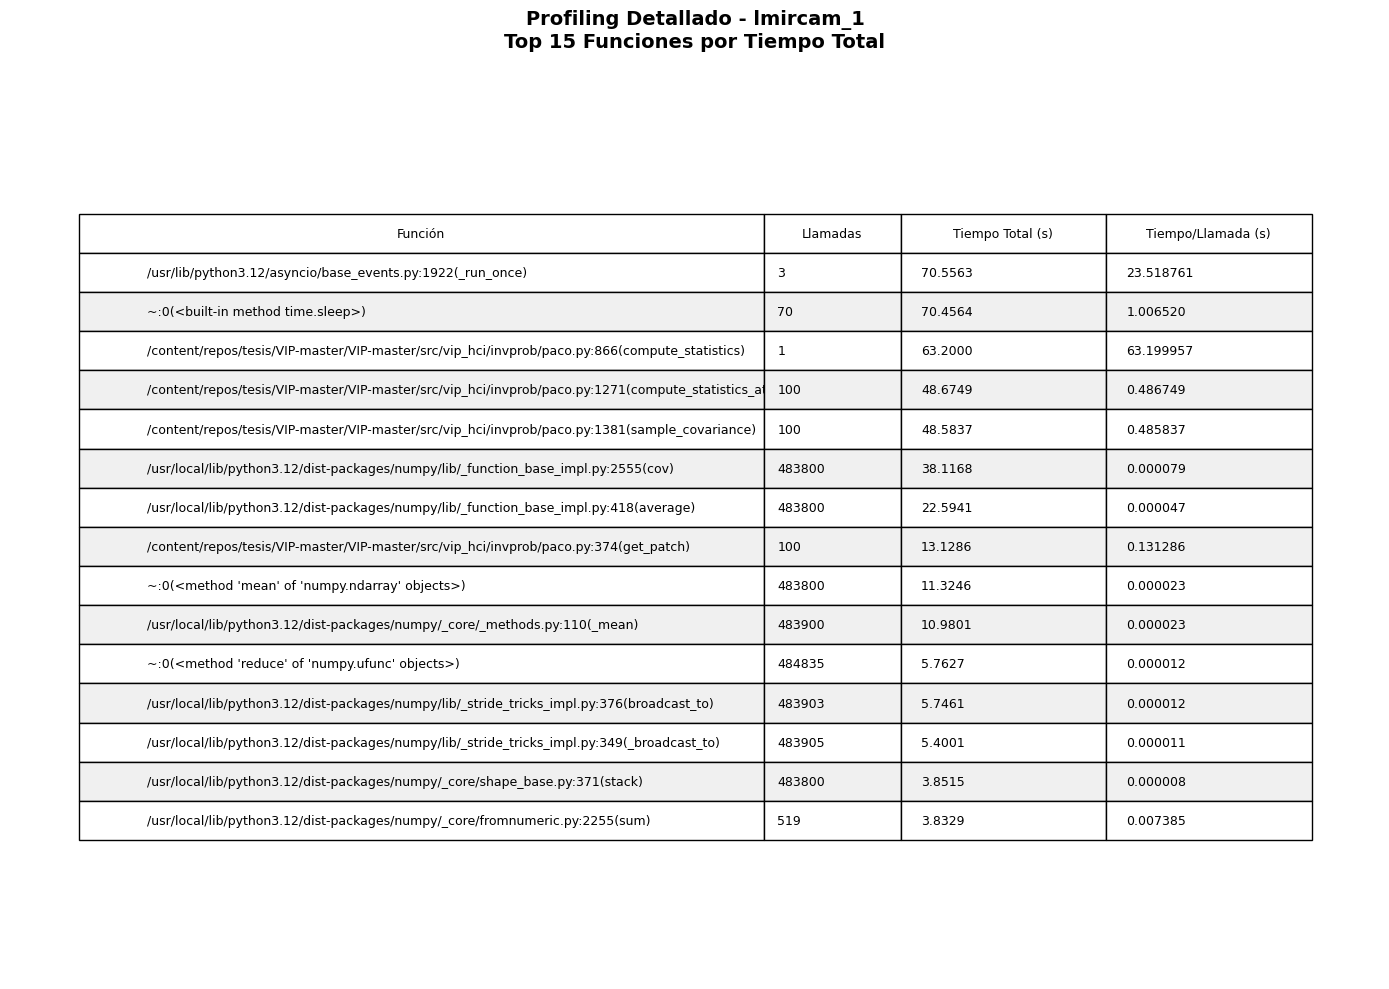


[OK] Profiling completado
  Total de funciones analizadas: 660
  Tiempo total: 449.9294 segundos


In [ ]:
# Profiling detallado con tabla profesional
print("="*70)
print("PROFILING DETALLADO DEL ALGORITMO")
print("="*70)

# Seleccionar el primer dataset exitoso para profiling
profile_dataset = None
for dataset_name, results in all_results.items():
    if results.get('success', False):
        profile_dataset = dataset_name
        break

if profile_dataset:
    # Manejar nombres con múltiples partes (ej: 'sphere_irdis_1' -> instrument='sphere_irdis', dataset_id='1')
    parts = profile_dataset.split('_')
    instrument = '_'.join(parts[:-1])  # Todo excepto el último
    dataset_id = int(parts[-1])  # El último es el ID

    print(f"\nEjecutando profiling para: {profile_dataset}")
    print("(Esto puede tardar unos minutos...)\n")

    # Recargar datos
    cube, angles, psf, pixscale = load_challenge_dataset_simple(
        repo_url=REPO_URL,
        instrument=instrument,
        dataset_id=dataset_id,
        branch='main'
    )

    fwhm_arcsec = 4.0 * pixscale

    # Ejecutar profiling
    try:
        a_prof, b_prof, profile_df, profiler = profile_paco_detailed(
            cube, angles, psf, pixscale, fwhm_arcsec
        )

        print("\n" + "="*70)
        print("TABLA DE TIEMPOS POR FUNCIÓN (Top 20)")
        print("="*70)

        # Mostrar tabla formateada
        pd.set_option('display.max_rows', None)
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', 50)

        # Formatear números
        display_df = profile_df.head(20).copy()
        display_df['Tiempo Total (s)'] = display_df['Tiempo Total (s)'].apply(lambda x: f"{x:.4f}")
        display_df['Tiempo por Llamada (s)'] = display_df['Tiempo por Llamada (s)'].apply(lambda x: f"{x:.6f}")
        display_df['Tiempo Acumulado (s)'] = display_df['Tiempo Acumulado (s)'].apply(lambda x: f"{x:.4f}")

        print(display_df.to_string(index=False))

        # Crear visualización de la tabla
        fig, ax = plt.subplots(figsize=(14, 10))
        ax.axis('tight')
        ax.axis('off')

        # Preparar datos para la tabla
        table_data = profile_df.head(15)[['Función', 'Llamadas', 'Tiempo Total (s)', 'Tiempo por Llamada (s)']].copy()
        table_data['Tiempo Total (s)'] = table_data['Tiempo Total (s)'].apply(lambda x: f"{x:.4f}")
        table_data['Tiempo por Llamada (s)'] = table_data['Tiempo por Llamada (s)'].apply(lambda x: f"{x:.6f}")

        table = ax.table(cellText=table_data.values,
                        colLabels=['Función', 'Llamadas', 'Tiempo Total (s)', 'Tiempo/Llamada (s)'],
                        cellLoc='left',
                        loc='center',
                        colWidths=[0.5, 0.1, 0.15, 0.15])

        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 2)

        # Colorear filas alternas
        for i in range(1, len(table_data) + 1):
            if i % 2 == 0:
                for j in range(4):
                    table[(i, j)].set_facecolor('#f0f0f0')

        plt.title(f'Profiling Detallado - {profile_dataset}\nTop 15 Funciones por Tiempo Total',
                 fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

        # Guardar perfil completo
        print(f"\n[OK] Profiling completado")
        print(f"  Total de funciones analizadas: {len(profile_df)}")
        print(f"  Tiempo total: {profile_df['Tiempo Total (s)'].sum():.4f} segundos")

    except Exception as e:
        print(f"[ERROR] Error en profiling: {e}")
        traceback.print_exc()
else:
    print("No hay datasets exitosos para profiling")


## 9. Validaciones Científicas (Detección y Análisis)


In [ ]:
# Validaciones científicas similares a DC1_starting_kit
print("="*70)
print("VALIDACIONES CIENTÍFICAS")
print("="*70)

def scientific_validation(results_dict, dataset_name, fwhm_pixels=4.0):
    """
    Realiza validaciones científicas: detecciones, umbrales, análisis de calidad
    """
    if dataset_name not in results_dict or not results_dict[dataset_name].get('success', False):
        return None

    results = results_dict[dataset_name]
    snr = results['snr']
    n_pixels = results['n_pixels']

    # Reshape
    side = int(np.sqrt(n_pixels))
    if side * side == n_pixels:
        snr_2d = snr.reshape(side, side)
    else:
        snr_2d = snr[:side*side].reshape(side, side)

    # Calcular FWHM en píxeles (aproximado)
    fwhm = fwhm_pixels

    # Análisis de detecciones con diferentes umbrales
    thresholds = [3, 4, 5, 6, 7]
    detections = {}

    # DIAGNÓSTICO: Mostrar estadísticas de SNR antes de calcular detecciones
    print(f"\n[DIAGNÓSTICO] Estadísticas de SNR para {dataset_name}:")
    print(f"  SNR máximo: {results['snr_max']:.2f}")
    print(f"  SNR medio: {results['snr_mean']:.2f}")
    print(f"  SNR mediana: {np.nanmedian(snr):.2f}")
    print(f"  Desv. estándar: {np.nanstd(snr):.2f}")
    print(f"  Píxeles con SNR > 3: {np.sum(snr_2d > 3)}")
    print(f"  Píxeles con SNR > 5: {np.sum(snr_2d > 5)}")
    print(f"  Píxeles con SNR > 7: {np.sum(snr_2d > 7)}")

    # Intentar usar photutils.detect_sources (método del starting kit)
    try:
        from photutils.segmentation import detect_sources

        for thresh in thresholds:
            # Usar detect_sources para agrupar píxeles conectados (blobs)
            # npix=2: mínimo de píxeles conectados para considerar una detección (como en starting kit)
            # connectivity=4: conectividad de 4 vecinos
            segments = detect_sources(snr_2d, thresh, npixels=2, connectivity=4)

            if segments is None:
                n_detections = 0
                n_pixels = 0
                detected_snr = []
            else:
                # Contar el número de blobs (detecciones) únicos
                n_detections = segments.nlabels
                # Contar píxeles totales en todos los blobs
                n_pixels = np.sum(segments.data != 0)
                # Obtener SNR de los píxeles detectados
                detected_snr = snr_2d[segments.data != 0]

            if n_detections > 0 and len(detected_snr) > 0:
                # Calcular SNR máximo por blob
                max_snr_per_blob = []
                for label_id in range(1, n_detections + 1):
                    blob_mask = segments.data == label_id
                    max_snr_per_blob.append(np.nanmax(snr_2d[blob_mask]))

                detections[thresh] = {
                    'count': n_detections,  # Número de blobs (detecciones reales)
                    'n_pixels': n_pixels,  # Número total de píxeles en blobs
                    'mean_snr': float(np.nanmean(detected_snr)),
                    'max_snr': float(np.nanmax(detected_snr)),
                    'mean_max_snr_per_blob': float(np.nanmean(max_snr_per_blob)),
                    'std_snr': float(np.nanstd(detected_snr))
                }
            else:
                detections[thresh] = {
                    'count': 0,
                    'n_pixels': 0,
                    'mean_snr': 0,
                    'max_snr': 0,
                    'mean_max_snr_per_blob': 0,
                    'std_snr': 0
                }
    except ImportError:
        print("[WARNING] photutils no disponible, usando scipy.ndimage como fallback")
        # Fallback: usar scipy.ndimage para clustering
        try:
            from scipy import ndimage

            for thresh in thresholds:
                mask = snr_2d > thresh
                n_pixels = np.sum(mask)

                if n_pixels > 0:
                    labeled_mask, n_detections = ndimage.label(mask)
                    detected_snr = snr_2d[mask]

                    # Calcular SNR máximo por blob
                    max_snr_per_blob = []
                    for label_id in range(1, n_detections + 1):
                        blob_mask = labeled_mask == label_id
                        max_snr_per_blob.append(np.nanmax(snr_2d[blob_mask]))

                    detections[thresh] = {
                        'count': n_detections,
                        'n_pixels': n_pixels,
                        'mean_snr': float(np.nanmean(detected_snr)),
                        'max_snr': float(np.nanmax(detected_snr)),
                        'mean_max_snr_per_blob': float(np.nanmean(max_snr_per_blob)) if max_snr_per_blob else 0,
                        'std_snr': float(np.nanstd(detected_snr))
                    }
                else:
                    detections[thresh] = {
                        'count': 0,
                        'n_pixels': 0,
                        'mean_snr': 0,
                        'max_snr': 0,
                        'mean_max_snr_per_blob': 0,
                        'std_snr': 0
                    }
        except ImportError:
            print("[WARNING] scipy.ndimage no disponible, usando conteo simple de píxeles")
            # Último fallback: contar píxeles individuales
            for thresh in thresholds:
                mask = snr_2d > thresh
                n_pixels = np.sum(mask)

                if n_pixels > 0:
                    detected_snr = snr_2d[mask]
                    detections[thresh] = {
                        'count': n_pixels,  # En este caso, cada píxel cuenta como detección
                        'n_pixels': n_pixels,
                        'mean_snr': float(np.nanmean(detected_snr)),
                        'max_snr': float(np.nanmax(detected_snr)),
                        'std_snr': float(np.nanstd(detected_snr))
                    }
                else:
                    detections[thresh] = {
                        'count': 0,
                        'n_pixels': 0,
                        'mean_snr': 0,
                        'max_snr': 0,
                        'std_snr': 0
                    }

    # Información sobre por qué puede no haber detecciones
    if all(detections[t]['count'] == 0 for t in [3, 5, 7]):
        print(f"\n[ANÁLISIS] Razones posibles para no tener detecciones:")
        print(f"  1. El dataset puede tener 0 señales inyectadas (según EIDC: 0-5 señales por dataset)")
        print(f"  2. SNR máximo ({results['snr_max']:.2f}) puede estar por debajo de los umbrales (3-7σ)")
        if results['snr_max'] < 3:
            print(f"     → SNR máximo < 3σ: Las señales pueden ser demasiado débiles")
        print(f"  3. Las señales pueden estar en regiones no procesadas (máscara interna)")
        print(f"  4. Los parámetros de PACO pueden necesitar ajuste (fwhm, patch_size, etc.)")
        print(f"  5. El algoritmo puede estar suprimiendo señales reales (sobre-substracción)")
        print(f"\n  NOTA: El método ahora agrupa píxeles conectados en 'blobs' (como el starting kit),")
        print(f"        por lo que cuenta detecciones reales, no píxeles individuales.")

    return detections



VALIDACIONES CIENTÍFICAS


In [ ]:
# Ejecutar validaciones científicas usando los resultados del benchmark
print("\n" + "="*70)
print("VALIDANDO RESULTADOS CIENTÍFICOS")
print("="*70)

if 'all_results' not in globals() or not all_results:
    print("[WARNING] No hay resultados de benchmark para validar")
    validation_results = {}
else:
    validation_results = {}
    for dataset_name, results in all_results.items():
        if not results.get('success', False):
            print(f"\n[SKIP] {dataset_name} no tuvo una ejecución exitosa")
            continue

        print(f"\n{'-'*50}")
        print(f"Validando: {dataset_name}")
        detections = scientific_validation(all_results, dataset_name)

        if detections:
            validation_results[dataset_name] = detections
            print(f"[OK] Validación completada para {dataset_name}")
        else:
            print(f"[INFO] Sin detecciones significativas para {dataset_name}")

    if validation_results:
        print(f"\n[OK] Validaciones registradas: {len(validation_results)}")
    else:
        print("\n[WARNING] No se registraron detecciones en las validaciones")




VALIDANDO RESULTADOS CIENTÍFICOS

--------------------------------------------------
Validando: lmircam_1

[DIAGNÓSTICO] Estadísticas de SNR para lmircam_1:
  SNR máximo: 12.23
  SNR medio: -0.01
  SNR mediana: -0.02
  Desv. estándar: 4.73
  Píxeles con SNR > 3: 23
  Píxeles con SNR > 5: 13
  Píxeles con SNR > 7: 9
[OK] Validación completada para lmircam_1

--------------------------------------------------
Validando: lmircam_2

[DIAGNÓSTICO] Estadísticas de SNR para lmircam_2:
  SNR máximo: 9.35
  SNR medio: 0.12
  SNR mediana: 0.15
  Desv. estándar: 3.28
  Píxeles con SNR > 3: 21
  Píxeles con SNR > 5: 3
  Píxeles con SNR > 7: 2
[OK] Validación completada para lmircam_2

[OK] Validaciones registradas: 2


## 10. Resumen Final y Exportación de Resultados



RESUMEN FINAL Y EXPORTACIÓN

TABLA RESUMEN DE RESULTADOS
  Dataset Exito Tiempo (s)  Píxeles SNR Máximo SNR Medio       Cube Shape
lmircam_1  [OK]      36.66      100      12.23     -0.01 (4838, 200, 200)
lmircam_2  [OK]      21.03      100       9.35      0.12 (3219, 200, 200)


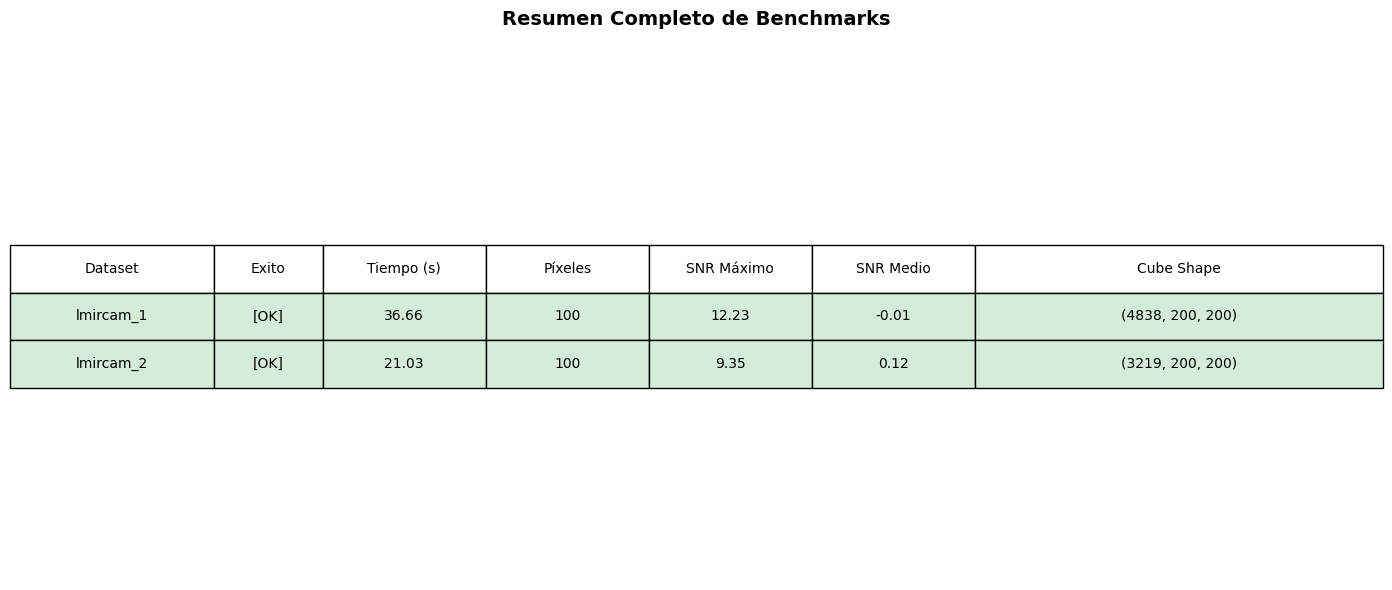


[OK] Resultados exportados a: /content/benchmark_results_summary.csv

RESUMEN FINAL
Total de datasets procesados: 2
Datasets exitosos: 2
Tiempo total de ejecución: 57.68 segundos

Validaciones científicas completadas: 2

  lmircam_1:
    - Detecciones SNR > 3σ: 2
    - Detecciones SNR > 5σ: 1
    - Detecciones SNR > 7σ: 2

  lmircam_2:
    - Detecciones SNR > 3σ: 5
    - Detecciones SNR > 5σ: 1
    - Detecciones SNR > 7σ: 1

FIN DEL BENCHMARK Y ANÁLISIS

Para más información sobre los errores encontrados, consulta:
  - ANALISIS_ERRORES_PACO_VIP.md
  - benchmark_paco_vip.py


In [ ]:
# Generar resumen completo y exportar resultados
print("\n" + "="*70)
print("RESUMEN FINAL Y EXPORTACIÓN")
print("="*70)

# Crear DataFrame con todos los resultados
summary_data = []
for dataset_name, results in all_results.items():
    if results.get('success', False):
        summary_data.append({
            'Dataset': dataset_name,
            'Exito': '[OK]',
            'Tiempo (s)': f"{results.get('time', 0):.2f}",
            'Píxeles': results.get('n_pixels', 0),
            'SNR Máximo': f"{results.get('snr_max', 0):.2f}",
            'SNR Medio': f"{results.get('snr_mean', 0):.2f}",
            'Cube Shape': str(results.get('cube_shape', 'N/A'))
        })
    else:
        summary_data.append({
            'Dataset': dataset_name,
            'Exito': '[ERROR]',
            'Tiempo (s)': 'N/A',
            'Píxeles': 'N/A',
            'SNR Máximo': 'N/A',
            'SNR Medio': 'N/A',
            'Cube Shape': 'N/A'
        })

summary_df = pd.DataFrame(summary_data)

# Mostrar tabla de resumen
print("\n" + "="*70)
print("TABLA RESUMEN DE RESULTADOS")
print("="*70)
print(summary_df.to_string(index=False))

# Crear visualización de la tabla
fig, ax = plt.subplots(figsize=(14, max(6, len(summary_data) * 0.5)))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=summary_df.values,
                colLabels=summary_df.columns,
                cellLoc='center',
                loc='center',
                colWidths=[0.15, 0.08, 0.12, 0.12, 0.12, 0.12, 0.3])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Colorear filas según éxito
for i in range(len(summary_data)):
    if summary_data[i]['Exito'] == '[OK]':
        for j in range(len(summary_df.columns)):
            table[(i+1, j)].set_facecolor('#d4edda')
    else:
        for j in range(len(summary_df.columns)):
            table[(i+1, j)].set_facecolor('#f8d7da')

plt.title('Resumen Completo de Benchmarks', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Exportar resultados a CSV
try:
    summary_df.to_csv('/content/benchmark_results_summary.csv', index=False)
    print("\n[OK] Resultados exportados a: /content/benchmark_results_summary.csv")
except Exception as e:
    print(f"\n[WARNING] No se pudo exportar CSV: {e}")

# Resumen final
print("\n" + "="*70)
print("RESUMEN FINAL")
print("="*70)
print(f"Total de datasets procesados: {len(all_results)}")
print(f"Datasets exitosos: {len([r for r in all_results.values() if r.get('success', False)])}")
print(f"Tiempo total de ejecución: {sum([r.get('time', 0) for r in all_results.values() if r.get('success', False)]):.2f} segundos")

if validation_results:
    print(f"\nValidaciones científicas completadas: {len(validation_results)}")
    for dataset_name, detections in validation_results.items():
        print(f"\n  {dataset_name}:")
        for thresh in [3, 5, 7]:
            if thresh in detections:
                print(f"    - Detecciones SNR > {thresh}σ: {detections[thresh]['count']}")

print("\n" + "="*70)
print("FIN DEL BENCHMARK Y ANÁLISIS")
print("="*70)
print("\nPara más información sobre los errores encontrados, consulta:")
print("  - ANALISIS_ERRORES_PACO_VIP.md")
print("  - benchmark_paco_vip.py")


## 7. Visualización de Resultados


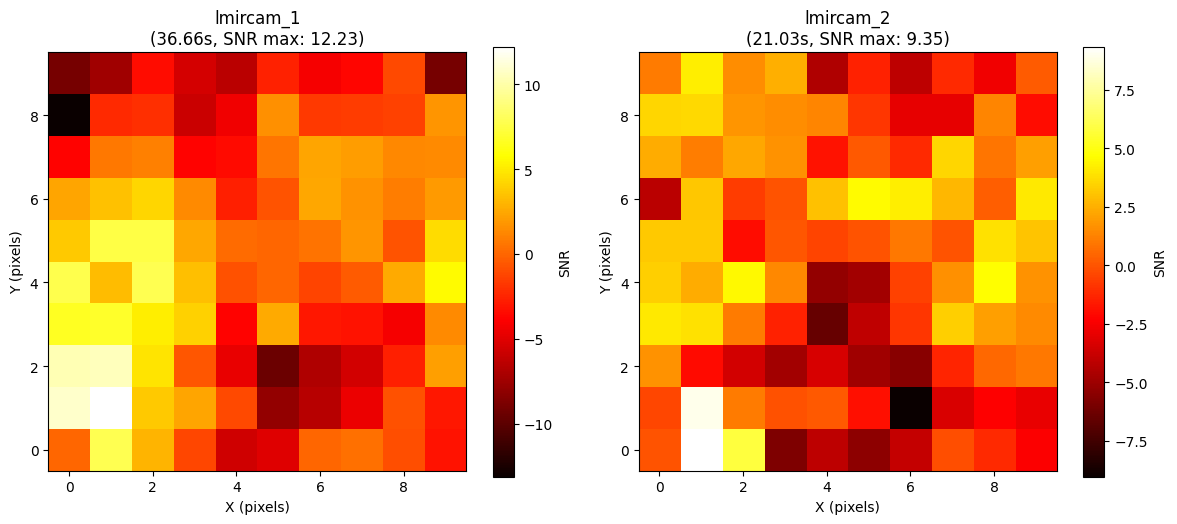

In [ ]:
# Crear visualizaciones
n_datasets = len([r for r in all_results.values() if r.get('success', False)])

if n_datasets > 0:
    fig, axes = plt.subplots(1, n_datasets, figsize=(6*n_datasets, 5))
    if n_datasets == 1:
        axes = [axes]

    plot_idx = 0
    for dataset_name, results in all_results.items():
        if results.get('success', False) and 'snr' in results:
            snr = results['snr']
            n_pixels = results['n_pixels']

            # Reshape para visualización
            side = int(np.sqrt(n_pixels))
            if side * side == n_pixels:
                snr_2d = snr.reshape(side, side)
            else:
                snr_2d = snr[:side*side].reshape(side, side)

            im = axes[plot_idx].imshow(snr_2d, origin='lower', cmap='hot')
            axes[plot_idx].set_title(f'{dataset_name}\n({results["time"]:.2f}s, SNR max: {results["snr_max"]:.2f})')
            axes[plot_idx].set_xlabel('X (pixels)')
            axes[plot_idx].set_ylabel('Y (pixels)')
            plt.colorbar(im, ax=axes[plot_idx], label='SNR')
            plot_idx += 1

    plt.tight_layout()
    plt.show()
else:
    print("No hay resultados exitosos para visualizar")


## 8. Resumen de Resultados


In [ ]:
# Generar resumen
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS")
print("="*70)

for dataset_name, results in all_results.items():
    print(f"\nDataset: {dataset_name}")
    print(f"  Exito: {'[OK]' if results.get('success', False) else '[ERROR]'}")

    if results.get('success', False):
        print(f"  Tiempo: {results.get('time', 0):.2f} segundos")
        print(f"  Píxeles procesados: {results.get('n_pixels', 0)}")
        print(f"  SNR máximo: {results.get('snr_max', 0):.2f}")
        print(f"  SNR medio: {results.get('snr_mean', 0):.2f}")
        if 'cube_shape' in results:
            print(f"  Cube shape: {results['cube_shape']}")
    else:
        print(f"  Errores:")
        for error in results.get('errors', []):
            print(f"    - {error}")

print("\n" + "="*70)
print("FIN DEL BENCHMARK")
print("="*70)
print("\nPara más información sobre los errores encontrados, consulta:")
print("  - ANALISIS_ERRORES_PACO_VIP.md")
print("  - benchmark_paco_vip.py")



RESUMEN DE RESULTADOS

Dataset: lmircam_1
  Exito: [OK]
  Tiempo: 36.66 segundos
  Píxeles procesados: 100
  SNR máximo: 12.23
  SNR medio: -0.01
  Cube shape: (4838, 200, 200)

Dataset: lmircam_2
  Exito: [OK]
  Tiempo: 21.03 segundos
  Píxeles procesados: 100
  SNR máximo: 9.35
  SNR medio: 0.12
  Cube shape: (3219, 200, 200)

FIN DEL BENCHMARK

Para más información sobre los errores encontrados, consulta:
  - ANALISIS_ERRORES_PACO_VIP.md
  - benchmark_paco_vip.py
